<a href="https://colab.research.google.com/github/19mddill/Autsim-Thesis/blob/main/Heavy_distinguishing_children_with_autism_specturm_disorder_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# CELL 1: CORE INSTALLS
# =========================
!pip -q install "numpy<2" mediapipe==0.10.21 opencv-python==4.11.0.86 scikit-learn pandas matplotlib seaborn tqdm pillow
!pip -q install transformers av accelerate

In [ ]:
# =========================
# CELL 2: IMPORTS
# =========================
import os
import glob
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

warnings.filterwarnings("ignore")

In [ ]:
# =========================
# CELL 3: DRIVE + CONFIG
# =========================
from google.colab import drive
drive.mount('/content/drive')

dataset_root = '/content/drive/MyDrive/autism_children_research_videos/'

labels = [
    "hand_flapping",
    "finger_cliping",
    "spining",
    "toe_walking",
    "tilting"
]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Dataset root:", dataset_root)
print("Dataset root exists:", os.path.exists(dataset_root))
print("Labels:", labels)

num_pose_frames = 30
num_video_frames = 16
image_size = 224

N_SPLITS = 3

STGCN_EPOCHS = 15
FLOW_EPOCHS = 8
VIDEOMAE_EPOCHS = 4

POSE_BATCH_SIZE = 8
FLOW_BATCH_SIZE = 4
VIDEOMAE_BATCH_SIZE = 2

POSE_LR = 1e-3
FLOW_LR = 1e-3
VIDEOMAE_LR = 5e-5

Mounted at /content/drive
Device: cpu
Dataset root: /content/drive/MyDrive/autism_children_research_videos/
Dataset root exists: True
Labels: ['hand_flapping', 'finger_cliping', 'spining', 'toe_walking', 'tilting']


In [ ]:
# =========================
# CELL 4: METADATA TABLE
# =========================
def build_metadata_table(dataset_root, labels):
    rows = []
    for lbl_idx, lbl in enumerate(labels):
        folder = os.path.join(dataset_root, lbl)
        files = sorted(
            glob.glob(os.path.join(folder, "*.mp4")) +
            glob.glob(os.path.join(folder, "*.avi"))
        )

        print(f"{lbl}: {len(files)} files")

        for p in files:
            rows.append({
                "video_path": p,
                "label_id": lbl_idx,
                "label_name": lbl,
                "sample_id": Path(p).stem
            })

    return pd.DataFrame(rows)

metadata_df = build_metadata_table(dataset_root, labels)

print("\nMetadata shape:", metadata_df.shape)
display(metadata_df.head())

print("\nClass counts:")
display(metadata_df["label_name"].value_counts())

hand_flapping: 54 files
finger_cliping: 45 files
spining: 5 files
toe_walking: 7 files
tilting: 14 files

Metadata shape: (125, 4)


,video_path,label_id,label_name,sample_id
0,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand__flapping_019
1,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand__flapping_020
2,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand__flapping_021
3,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand_flapping_001
4,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand_flapping_002



Class counts:


,count
label_name,
hand_flapping,54
finger_cliping,45
tilting,14
toe_walking,7
spining,5


In [ ]:
# =========================
# CELL 5: POSE EXTRACTION
# =========================
mp_pose = mp.solutions.pose

def extract_pose_sequence_from_video(video_path, num_frames_out=30, resize_width=640):
    cap = cv2.VideoCapture(video_path)
    frames = []

    success, frame = cap.read()
    while success:
        if resize_width:
            h, w = frame.shape[:2]
            new_h = int(h * (resize_width / float(w)))
            frame = cv2.resize(frame, (resize_width, new_h))
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        success, frame = cap.read()

    cap.release()

    if len(frames) == 0:
        return None

    pose = mp_pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        min_detection_confidence=0.4,
        min_tracking_confidence=0.4
    )

    seq = []
    for img in frames:
        results = pose.process(img)
        if results.pose_landmarks:
            row = []
            for lm in results.pose_landmarks.landmark:
                row.extend([lm.x, lm.y, lm.visibility])
        else:
            row = [0.0] * (33 * 3)
        seq.append(row)

    pose.close()

    seq = np.array(seq, dtype=np.float32)  # (T, 99)
    T = seq.shape[0]

    if T == num_frames_out:
        return seq
    elif T < num_frames_out:
        pad_cnt = num_frames_out - T
        last = seq[-1]
        seq = np.vstack([seq, np.tile(last, (pad_cnt, 1))])
        return seq
    else:
        idx = np.linspace(0, T - 1, num_frames_out).astype(int)
        return seq[idx]

In [ ]:
# =========================
# CELL 6: HELPERS
# =========================
def temporal_crop(seq, out_len):
    T = seq.shape[0]
    if T <= out_len:
        pad = np.tile(seq[-1], (out_len - T, 1))
        return np.vstack([seq, pad])
    start = np.random.randint(0, T - out_len + 1)
    return seq[start:start + out_len]

def time_warp(seq, scale=0.9):
    T = seq.shape[0]
    new_T = max(5, int(round(T * scale)))
    idx = np.linspace(0, T - 1, new_T).astype(int)
    seq2 = seq[idx]
    idx2 = np.linspace(0, new_T - 1, T).astype(int)
    return seq2[idx2]

def horiz_flip(seq):
    seq2 = np.copy(seq)
    seq2[:, ::3] = 1.0 - seq2[:, ::3]
    return seq2

def pose_train_augment(seq, out_len=num_pose_frames):
    seq = seq.copy()
    if random.random() < 0.6:
        seq = time_warp(seq, scale=random.uniform(0.85, 1.15))
    if random.random() < 0.6:
        seq = temporal_crop(seq, out_len)
    if random.random() < 0.5:
        seq = horiz_flip(seq)
    return seq.astype(np.float32)

def extract_rgb_clip(video_path, num_frames_out=16, image_size=224):
    cap = cv2.VideoCapture(video_path)
    frames = []

    success, frame = cap.read()
    while success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (image_size, image_size))
        frames.append(frame)
        success, frame = cap.read()

    cap.release()

    if len(frames) == 0:
        return None

    if len(frames) == num_frames_out:
        sampled = frames
    elif len(frames) < num_frames_out:
        sampled = frames + [frames[-1]] * (num_frames_out - len(frames))
    else:
        idx = np.linspace(0, len(frames) - 1, num_frames_out).astype(int)
        sampled = [frames[i] for i in idx]

    return np.array(sampled, dtype=np.uint8)

def dense_flow_to_rgb(prev_rgb, next_rgb):
    prev_gray = cv2.cvtColor(prev_rgb, cv2.COLOR_RGB2GRAY)
    next_gray = cv2.cvtColor(next_rgb, cv2.COLOR_RGB2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, next_gray, None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )

    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    hsv = np.zeros((prev_gray.shape[0], prev_gray.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 1] = 255
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return rgb

def extract_flow_clip(video_path, num_frames_out=16, image_size=224):
    rgb_clip = extract_rgb_clip(video_path, num_frames_out=num_frames_out, image_size=image_size)
    if rgb_clip is None:
        return None

    flow_frames = []
    for i in range(len(rgb_clip) - 1):
        flow_frames.append(dense_flow_to_rgb(rgb_clip[i], rgb_clip[i + 1]))

    if len(flow_frames) == 0:
        flow_frames = [np.zeros_like(rgb_clip[0])]

    return np.array(flow_frames, dtype=np.uint8)

In [ ]:
# =========================
# CELL 6A: FIXED-TARGET BALANCING HELPERS
# =========================
TARGET_PER_CLASS = 50

def balance_train_df_to_target(train_df, label_col="label_id", target_count=50, random_state=42, downsample_majority=False):
    """
    Balance ONLY the TRAIN FOLD to a fixed target per class.

    - If a class has fewer than target_count, duplicate rows up to target_count.
    - If downsample_majority=True and a class has more than target_count, sample it down.
    - Original rows get augmented=False
    - Duplicated rows get augmented=True
    """
    train_df = train_df.copy().reset_index(drop=True)
    train_df["augmented"] = False

    balanced_parts = []

    classes = sorted(train_df[label_col].unique())

    for cls_id in classes:
        cls_rows = train_df[train_df[label_col] == cls_id].copy()
        n = len(cls_rows)

        if n < target_count:
            need = target_count - n
            extra = cls_rows.sample(n=need, replace=True, random_state=random_state).copy()
            extra["augmented"] = True
            cls_balanced = pd.concat([cls_rows, extra], ignore_index=True)

        elif n > target_count and downsample_majority:
            cls_balanced = cls_rows.sample(n=target_count, replace=False, random_state=random_state).copy()
            cls_balanced["augmented"] = False

        else:
            cls_balanced = cls_rows.copy()

        balanced_parts.append(cls_balanced)

    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced_df

def print_fold_class_counts(title, df):
    counts = df["label_name"].value_counts().sort_index().to_dict()
    print(title)
    print(counts)

def augment_rgb_clip(rgb_clip, image_size=224):
    """
    Apply the SAME augmentation to all frames of a clip.
    For duplicated minority samples only.
    """
    clip = rgb_clip.copy()

    # Horizontal flip
    if random.random() < 0.5:
        clip = np.flip(clip, axis=2).copy()

    # Mild brightness/contrast
    if random.random() < 0.5:
        alpha = random.uniform(0.90, 1.10)
        beta = random.uniform(-10, 10)
        clip = np.clip(clip.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    # Mild crop + resize back
    if random.random() < 0.5:
        T, H, W, C = clip.shape
        scale = random.uniform(0.88, 1.00)
        new_h = max(32, int(H * scale))
        new_w = max(32, int(W * scale))
        y1 = random.randint(0, H - new_h)
        x1 = random.randint(0, W - new_w)

        cropped = []
        for frame in clip:
            crop = frame[y1:y1+new_h, x1:x1+new_w]
            crop = cv2.resize(crop, (image_size, image_size))
            cropped.append(crop)

        clip = np.array(cropped, dtype=np.uint8)

    return clip

def rgb_to_flow_clip(rgb_clip):
    flow_frames = []
    for i in range(len(rgb_clip) - 1):
        flow_frames.append(dense_flow_to_rgb(rgb_clip[i], rgb_clip[i + 1]))

    if len(flow_frames) == 0:
        flow_frames = [np.zeros_like(rgb_clip[0])]

    return np.array(flow_frames, dtype=np.uint8)

In [ ]:
# =========================
# CELL 7: BUILD POSE CACHE
# =========================
def build_pose_cache(metadata_df, num_frames=30):
    pose_cache = {}
    valid_rows = []

    for _, row in tqdm.tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        p = row["video_path"]
        seq = extract_pose_sequence_from_video(p, num_frames_out=num_frames)
        if seq is None:
            print("Skipping bad clip:", p)
            continue

        pose_cache[p] = seq.astype(np.float32)
        valid_rows.append(row)

    clean_df = pd.DataFrame(valid_rows).reset_index(drop=True)
    return clean_df, pose_cache

clean_df, pose_cache = build_pose_cache(metadata_df, num_frames=num_pose_frames)

print("Valid original clips:", len(clean_df))
display(clean_df.head())

print("\nClass counts after pose validation:")
display(clean_df["label_name"].value_counts())

100%|██████████| 125/125 [06:34<00:00,  3.15s/it]

Valid original clips: 125


,video_path,label_id,label_name,sample_id
0,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand__flapping_019
1,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand__flapping_020
2,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand__flapping_021
3,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand_flapping_001
4,/content/drive/MyDrive/autism_children_researc...,0,hand_flapping,hand_flapping_002



Class counts after pose validation:


,count
label_name,
hand_flapping,54
finger_cliping,45
tilting,14
toe_walking,7
spining,5


In [ ]:
# =========================
# CELL 8: SHARED UTILITIES
# =========================
def fit_pose_norm(train_paths, pose_cache):
    X = np.concatenate([pose_cache[p] for p in train_paths], axis=0)
    mean = X.mean(axis=0).astype(np.float32)
    std = (X.std(axis=0) + 1e-6).astype(np.float32)
    return mean, std

def normalize_pose(seq, mean, std):
    return ((seq - mean) / std).astype(np.float32)

def make_class_weights(y_train, num_classes):
    counts = Counter(y_train)
    total = len(y_train)
    weights = []
    for i in range(num_classes):
        c = counts.get(i, 1)
        weights.append(total / (num_classes * c))
    return torch.tensor(weights, dtype=torch.float32, device=device)

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def summarize_cv(df):
    return pd.DataFrame({
        "mean_accuracy": [df["Accuracy"].mean()],
        "std_accuracy": [df["Accuracy"].std()],
        "min_accuracy": [df["Accuracy"].min()],
        "max_accuracy": [df["Accuracy"].max()],
    })

def train_epoch_standard(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(y.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

@torch.no_grad()
def eval_epoch_standard(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * y.size(0)
        y_true.extend(y.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "cm": cm,
        "report": report,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_prob": np.array(y_prob),
    }

def train_epoch_hf(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    y_true, y_pred = [], []

    for batch in loader:
        pixel_values = batch["pixel_values"].to(device)
        labels_batch = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels_batch)
        loss = outputs.loss
        logits = outputs.logits
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels_batch.size(0)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels_batch.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

@torch.no_grad()
def eval_epoch_hf(model, loader):
    model.eval()
    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for batch in loader:
        pixel_values = batch["pixel_values"].to(device)
        labels_batch = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels_batch)
        loss = outputs.loss
        logits = outputs.logits

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * labels_batch.size(0)
        y_true.extend(labels_batch.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "cm": cm,
        "report": report,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_prob": np.array(y_prob),
    }

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

In [ ]:
# =========================
# CELL 9: SHARED POSE DATASET
# =========================
class PoseSequenceDataset(Dataset):
    def __init__(self, df, pose_cache, mean, std, train_mode=False, as_graph=False):
        self.df = df.reset_index(drop=True)
        self.pose_cache = pose_cache
        self.mean = mean
        self.std = std
        self.train_mode = train_mode
        self.as_graph = as_graph

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = self.pose_cache[row["video_path"]].copy()

        aug_flag = bool(row["augmented"]) if "augmented" in row.index else False
        if self.train_mode and aug_flag:
            seq = pose_train_augment(seq, out_len=num_pose_frames)

        seq = normalize_pose(seq, self.mean, self.std)

        if self.as_graph:
            seq = seq.reshape(seq.shape[0], 33, 3)

        x = torch.tensor(seq, dtype=torch.float32)
        y = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return x, y

In [ ]:
# =========================
# CELL 10: ST-GCN
# =========================
def build_mediapipe_adjacency(num_nodes=33):
    A = np.eye(num_nodes, dtype=np.float32)
    for i, j in mp_pose.POSE_CONNECTIONS:
        A[i, j] = 1.0
        A[j, i] = 1.0

    D = np.sum(A, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-6))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    return torch.tensor(A_norm, dtype=torch.float32)

A_MP = build_mediapipe_adjacency()

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, A, temporal_kernel=9, dropout=0.2):
        super().__init__()
        self.register_buffer("A", A)
        self.theta = nn.Linear(in_channels, out_channels, bias=False)

        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=(temporal_kernel, 1),
                padding=(temporal_kernel // 2, 0)
            ),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(dropout)
        )

        if in_channels == out_channels:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x_proj = self.theta(x)
        x_g = torch.einsum("ij,btjd->btid", self.A, x_proj)

        y = x_g.permute(0, 3, 1, 2)
        res = self.residual(x.permute(0, 3, 1, 2))
        y = self.tcn(y) + res
        y = F.relu(y)
        return y.permute(0, 2, 3, 1)

class STGCNClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.data_bn = nn.BatchNorm1d(33 * 3)
        self.block1 = STGCNBlock(3, 64, A_MP)
        self.block2 = STGCNBlock(64, 128, A_MP)
        self.block3 = STGCNBlock(128, 256, A_MP)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        B, T, V, C = x.shape

        x = x.reshape(B, T, V * C)
        x = self.data_bn(x.transpose(1, 2)).transpose(1, 2)
        x = x.reshape(B, T, V, C)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.permute(0, 3, 1, 2)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.flatten(1)
        x = self.dropout(x)
        return self.fc(x)

def run_stgcn_cv(clean_df, pose_cache, epochs=15, batch_size=8, lr=1e-3):
    rows = []
    fold_outputs = []

    X = clean_df["video_path"].values
    y = clean_df["label_id"].values

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n===== ST-GCN Fold {fold}/{N_SPLITS} =====")

        train_df = clean_df.iloc[tr_idx].reset_index(drop=True)
        test_df = clean_df.iloc[te_idx].reset_index(drop=True)

        print_fold_class_counts("Train counts before balancing:", train_df)
        balanced_train_df = balance_train_df_to_target(
          train_df,
          label_col="label_id",
          target_count=TARGET_PER_CLASS,
          random_state=SEED + fold,
          downsample_majority=False
        )
        print_fold_class_counts("Train counts after balancing:", balanced_train_df)

        mean, std = fit_pose_norm(train_df["video_path"].tolist(), pose_cache)

        train_ds = PoseSequenceDataset(
            balanced_train_df, pose_cache, mean, std,
            train_mode=True, as_graph=True
        )
        test_ds = PoseSequenceDataset(
            test_df, pose_cache, mean, std,
            train_mode=False, as_graph=True
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

        model = STGCNClassifier(num_classes=len(labels)).to(device)
        class_weights = make_class_weights(balanced_train_df["label_id"].tolist(), len(labels))
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

        for epoch in range(epochs):
            tr_loss, tr_acc = train_epoch_standard(model, train_loader, optimizer, criterion)
            if epoch == 0 or (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1:02d} | train_loss={tr_loss:.4f} | train_acc={tr_acc:.4f}")

        out = eval_epoch_standard(model, test_loader, criterion)
        print(f"Fold {fold} Accuracy: {out['accuracy']:.4f}")
        print(out["report"])

        rows.append({"Model": "ST-GCN", "Fold": fold, "Accuracy": out["accuracy"]})
        fold_outputs.append(out)

    return pd.DataFrame(rows), fold_outputs

In [ ]:
# =========================
# CELL 11: OPTICAL FLOW + MOBILENETV2
# =========================
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

class FlowDataset(Dataset):
    def __init__(self, df, num_frames=16, image_size=224, train_mode=False):
        self.df = df.reset_index(drop=True)
        self.num_frames = num_frames
        self.image_size = image_size
        self.train_mode = train_mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        rgb_clip = extract_rgb_clip(
            row["video_path"],
            num_frames_out=self.num_frames,
            image_size=self.image_size
        )

        if rgb_clip is None:
            rgb_clip = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)

        aug_flag = bool(row["augmented"]) if "augmented" in row.index else False
        if self.train_mode and aug_flag:
            rgb_clip = augment_rgb_clip(rgb_clip, image_size=self.image_size)

        flow_clip = rgb_to_flow_clip(rgb_clip)

        x = torch.tensor(flow_clip, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
        x = (x - IMAGENET_MEAN) / IMAGENET_STD

        y = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return x, y

class FlowMobileNetClassifier(nn.Module):
    def __init__(self, num_classes=5, freeze_backbone=True):
        super().__init__()
        backbone = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(1280, num_classes)

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feat = self.features(x)
        feat = self.pool(feat).flatten(1)
        feat = feat.view(B, T, -1).mean(dim=1)
        feat = self.dropout(feat)
        return self.fc(feat)

def run_flow_mobilenet_cv(clean_df, epochs=8, batch_size=4, lr=1e-3,
                          num_frames=16, image_size=224, freeze_backbone=True):
    rows = []
    fold_outputs = []

    X = clean_df["video_path"].values
    y = clean_df["label_id"].values

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n===== OpticalFlow+MobileNetV2 Fold {fold}/{N_SPLITS} =====")

        train_df = clean_df.iloc[tr_idx].reset_index(drop=True)
        test_df = clean_df.iloc[te_idx].reset_index(drop=True)

        print_fold_class_counts("Train counts before balancing:", train_df)
        balanced_train_df = balance_train_df_to_target(
          train_df,
          label_col="label_id",
          target_count=TARGET_PER_CLASS,
          random_state=SEED + fold,
          downsample_majority=False
        )
        print_fold_class_counts("Train counts after balancing:", balanced_train_df)

        train_ds = FlowDataset(
            balanced_train_df,
            num_frames=num_frames,
            image_size=image_size,
            train_mode=True
        )
        test_ds = FlowDataset(
            test_df,
            num_frames=num_frames,
            image_size=image_size,
            train_mode=False
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

        model = FlowMobileNetClassifier(
            num_classes=len(labels),
            freeze_backbone=freeze_backbone
        ).to(device)

        class_weights = make_class_weights(balanced_train_df["label_id"].tolist(), len(labels))
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, weight_decay=1e-4
        )

        for epoch in range(epochs):
            tr_loss, tr_acc = train_epoch_standard(model, train_loader, optimizer, criterion)
            if epoch == 0 or (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1:02d} | train_loss={tr_loss:.4f} | train_acc={tr_acc:.4f}")

        out = eval_epoch_standard(model, test_loader, criterion)
        print(f"Fold {fold} Accuracy: {out['accuracy']:.4f}")
        print(out["report"])

        rows.append({"Model": "OpticalFlow+MobileNetV2", "Fold": fold, "Accuracy": out["accuracy"]})
        fold_outputs.append(out)

    return pd.DataFrame(rows), fold_outputs

In [ ]:
# =========================
# CELL 12: VIDEOMAE
# =========================
VIDEOMAE_CKPT = "MCG-NJU/videomae-base"
videomae_processor = VideoMAEImageProcessor.from_pretrained(VIDEOMAE_CKPT)

label2id = {lbl: i for i, lbl in enumerate(labels)}
id2label = {i: lbl for lbl, i in label2id.items()}

class VideoMAEDataset(Dataset):
    def __init__(self, df, processor, num_frames=16, image_size=224, train_mode=False):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.num_frames = num_frames
        self.image_size = image_size
        self.train_mode = train_mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frames = extract_rgb_clip(
            row["video_path"],
            num_frames_out=self.num_frames,
            image_size=self.image_size
        )

        if frames is None:
            frames = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)

        aug_flag = bool(row["augmented"]) if "augmented" in row.index else False
        if self.train_mode and aug_flag:
            frames = augment_rgb_clip(frames, image_size=self.image_size)

        enc = self.processor(list(frames), return_tensors="pt")
        pixel_values = enc["pixel_values"].squeeze(0)

        label_tensor = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return {"pixel_values": pixel_values, "labels": label_tensor}

def videomae_collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels_batch = torch.stack([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels_batch}

def run_videomae_cv(clean_df, epochs=4, batch_size=2, lr=5e-5,
                    num_frames=16, image_size=224, freeze_backbone=False):
    rows = []
    fold_outputs = []

    X = clean_df["video_path"].values
    y = clean_df["label_id"].values

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n===== VideoMAE Fold {fold}/{N_SPLITS} =====")

        train_df = clean_df.iloc[tr_idx].reset_index(drop=True)
        test_df = clean_df.iloc[te_idx].reset_index(drop=True)

        print_fold_class_counts("Train counts before balancing:", train_df)
        balanced_train_df = balance_train_df_to_target(
          train_df,
          label_col="label_id",
          target_count=TARGET_PER_CLASS,
          random_state=SEED + fold,
          downsample_majority=False
        )
        print_fold_class_counts("Train counts after balancing:", balanced_train_df)

        train_ds = VideoMAEDataset(
            balanced_train_df,
            videomae_processor,
            num_frames=num_frames,
            image_size=image_size,
            train_mode=True
        )
        test_ds = VideoMAEDataset(
            test_df,
            videomae_processor,
            num_frames=num_frames,
            image_size=image_size,
            train_mode=False
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
            collate_fn=videomae_collate_fn
        )
        test_loader = DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            collate_fn=videomae_collate_fn
        )

        model = VideoMAEForVideoClassification.from_pretrained(
            VIDEOMAE_CKPT,
            num_labels=len(labels),
            label2id=label2id,
            id2label=id2label,
            ignore_mismatched_sizes=True
        ).to(device)

        if freeze_backbone:
            for name, p in model.named_parameters():
                if "classifier" not in name:
                    p.requires_grad = False

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, weight_decay=1e-4
        )

        for epoch in range(epochs):
            tr_loss, tr_acc = train_epoch_hf(model, train_loader, optimizer)
            print(f"Epoch {epoch+1:02d} | train_loss={tr_loss:.4f} | train_acc={tr_acc:.4f}")

        out = eval_epoch_hf(model, test_loader)
        print(f"Fold {fold} Accuracy: {out['accuracy']:.4f}")
        print(out["report"])

        rows.append({"Model": "VideoMAE", "Fold": fold, "Accuracy": out["accuracy"]})
        fold_outputs.append(out)

    return pd.DataFrame(rows), fold_outputs

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]


===== ST-GCN Fold 1/3 =====
Train counts before balancing:
{'finger_cliping': 30, 'hand_flapping': 36, 'spining': 3, 'tilting': 9, 'toe_walking': 5}
Train counts after balancing:
{'finger_cliping': 50, 'hand_flapping': 50, 'spining': 50, 'tilting': 50, 'toe_walking': 50}
Epoch 01 | train_loss=1.4263 | train_acc=0.4360
Epoch 05 | train_loss=1.0902 | train_acc=0.5640
Epoch 10 | train_loss=0.6780 | train_acc=0.7560
Epoch 15 | train_loss=0.6151 | train_acc=0.7760
Fold 1 Accuracy: 0.3810
                precision    recall  f1-score   support

 hand_flapping       0.54      0.39      0.45        18
finger_cliping       0.42      0.33      0.37        15
       spining       0.00      0.00      0.00         2
   toe_walking       0.00      0.00      0.00         2
       tilting       0.80      0.80      0.80         5

      accuracy                           0.38        42
     macro avg       0.35      0.30      0.32        42
  weighted avg       0.47      0.38      0.42        42


===

,Model,Fold,Accuracy
0,ST-GCN,1,0.380952
1,ST-GCN,2,0.500000
2,ST-GCN,3,0.585366


,mean_accuracy,std_accuracy,min_accuracy,max_accuracy
0,0.488773,0.102668,0.380952,0.585366


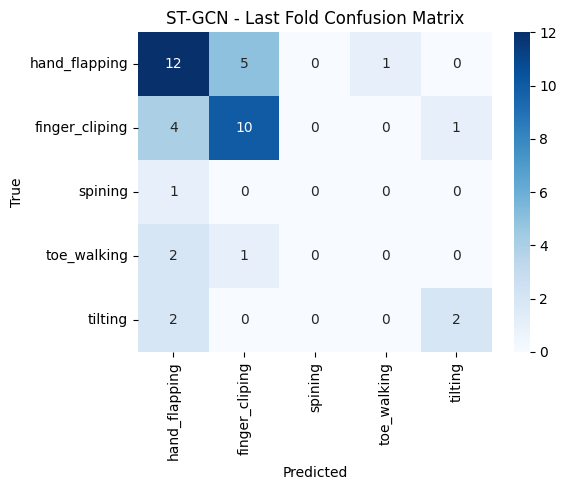

In [ ]:
# =========================
# CELL 13: RUN ST-GCN
# =========================
stgcn_cv_df, stgcn_outputs = run_stgcn_cv(
    clean_df,
    pose_cache,
    epochs=STGCN_EPOCHS,
    batch_size=POSE_BATCH_SIZE,
    lr=POSE_LR
)

display(stgcn_cv_df)
display(summarize_cv(stgcn_cv_df))

plot_confusion_matrix(
    stgcn_outputs[-1]["cm"],
    labels,
    title="ST-GCN - Last Fold Confusion Matrix"
)

In [ ]:
# =========================
# CELL 14: MAMBA SKIPPED
# =========================
print("Mamba is intentionally skipped in this Colab notebook because its installation was hanging.")
print("This notebook evaluates:")
print("1. ST-GCN")
print("2. Optical Flow + MobileNetV2")
print("3. VideoMAE")

Mamba is intentionally skipped in this Colab notebook because its installation was hanging.
This notebook evaluates:
1. ST-GCN
2. Optical Flow + MobileNetV2
3. VideoMAE



===== OpticalFlow+MobileNetV2 Fold 1/3 =====
Train counts before balancing:
{'finger_cliping': 30, 'hand_flapping': 36, 'spining': 3, 'tilting': 9, 'toe_walking': 5}
Train counts after balancing:
{'finger_cliping': 50, 'hand_flapping': 50, 'spining': 50, 'tilting': 50, 'toe_walking': 50}
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 232MB/s]


Epoch 01 | train_loss=1.6144 | train_acc=0.2600
Epoch 02 | train_loss=1.4716 | train_acc=0.4040
Epoch 04 | train_loss=1.2885 | train_acc=0.5400
Epoch 06 | train_loss=1.1870 | train_acc=0.5560
Epoch 08 | train_loss=1.0485 | train_acc=0.6600
Fold 1 Accuracy: 0.3810
                precision    recall  f1-score   support

 hand_flapping       0.48      0.72      0.58        18
finger_cliping       0.50      0.07      0.12        15
       spining       0.00      0.00      0.00         2
   toe_walking       0.00      0.00      0.00         2
       tilting       0.25      0.40      0.31         5

      accuracy                           0.38        42
     macro avg       0.25      0.24      0.20        42
  weighted avg       0.41      0.38      0.33        42


===== OpticalFlow+MobileNetV2 Fold 2/3 =====
Train counts before balancing:
{'finger_cliping': 30, 'hand_flapping': 36, 'spining': 3, 'tilting': 9, 'toe_walking': 5}
Train counts after balancing:
{'finger_cliping': 50, 'hand_fla

,Model,Fold,Accuracy
0,OpticalFlow+MobileNetV2,1,0.380952
1,OpticalFlow+MobileNetV2,2,0.357143
2,OpticalFlow+MobileNetV2,3,0.341463


,mean_accuracy,std_accuracy,min_accuracy,max_accuracy
0,0.359853,0.019883,0.341463,0.380952


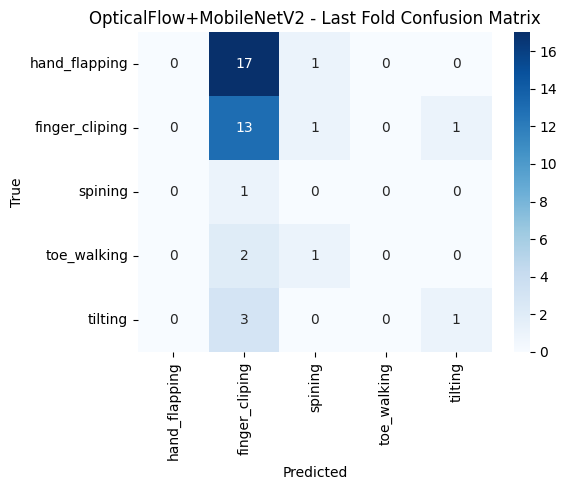

In [ ]:
# =========================
# CELL 15: RUN FLOW + MOBILENETV2
# =========================
flow_cv_df, flow_outputs = run_flow_mobilenet_cv(
    clean_df,
    epochs=FLOW_EPOCHS,
    batch_size=FLOW_BATCH_SIZE,
    lr=FLOW_LR,
    num_frames=num_video_frames,
    image_size=image_size,
    freeze_backbone=True
)

display(flow_cv_df)
display(summarize_cv(flow_cv_df))

plot_confusion_matrix(
    flow_outputs[-1]["cm"],
    labels,
    title="OpticalFlow+MobileNetV2 - Last Fold Confusion Matrix"
)

In [ ]:
# =========================
# CELL 16: RUN VIDEOMAE
# =========================
videomae_cv_df, videomae_outputs = run_videomae_cv(
    clean_df,
    epochs=VIDEOMAE_EPOCHS,
    batch_size=VIDEOMAE_BATCH_SIZE,
    lr=VIDEOMAE_LR,
    num_frames=num_video_frames,
    image_size=image_size,
    freeze_backbone=False
)

display(videomae_cv_df)
display(summarize_cv(videomae_cv_df))

plot_confusion_matrix(
    videomae_outputs[-1]["cm"],
    labels,
    title="VideoMAE - Last Fold Confusion Matrix"
)


===== VideoMAE Fold 1/3 =====
Train counts before balancing:
{'finger_cliping': 30, 'hand_flapping': 36, 'spining': 3, 'tilting': 9, 'toe_walking': 5}
Train counts after balancing:
{'finger_cliping': 50, 'hand_flapping': 50, 'spining': 50, 'tilting': 50, 'toe_walking': 50}


config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED | 
decoder.head.bias                                                    | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECT

Epoch 01 | train_loss=1.2258 | train_acc=0.4680


In [ ]:
# =========================
# CELL 17: FINAL SUMMARY
# =========================
all_results_df = pd.concat([stgcn_cv_df, flow_cv_df, videomae_cv_df], ignore_index=True)

summary_df = (
    all_results_df
    .groupby("Model")["Accuracy"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("\nFinal CV Summary:")
display(summary_df)

plt.figure(figsize=(9, 5))
plt.bar(summary_df.index, summary_df["mean"])
plt.ylabel("Mean CV Accuracy")
plt.title("Comparison of New Algorithms (Mamba Skipped)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()